In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

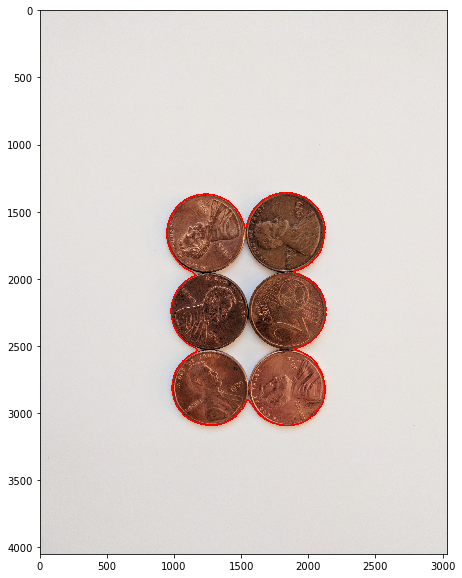

In [ ]:
path = "C:/Users/monukoru/Downloads/image processing python/DATA/pennies.jpg"
img = cv2.imread(path)
plt.figure(figsize=(10,10))

#we will do these thing in order for the contour
# grayscale
# median blur
# threshold
# contour

img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
coin_gray= cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
coin_blur= cv2.medianBlur(coin_gray, ksize=7)
ret,coin_thresh= cv2.threshold(coin_blur, 160,255, cv2.THRESH_BINARY_INV)

_,contour,__ = cv2.findContours(coin_thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

s=cv2.drawContours(img, contour, -1, (255,0,0), thickness=10)

plt.imshow(s)

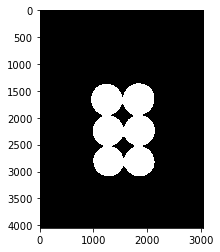

In [ ]:
# here we just converted to grayscale andblurred more using medianBLur
coin_med_blur = cv2.medianBlur(coin_gray,35)
ret_w,coin_thresh_water  = cv2.threshold(coin_med_blur, 160, 255, cv2.THRESH_BINARY_INV+cv2.THRESH_OTSU)  
plt.imshow(coin_thresh_water, cmap='gray')

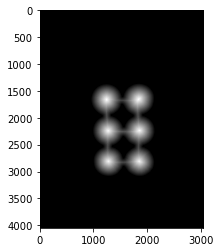

In [137]:
dist_transform= cv2.distanceTransform(coin_thresh_water, cv2.DIST_L2, 5)
plt.imshow(dist_transform, cmap='gray')

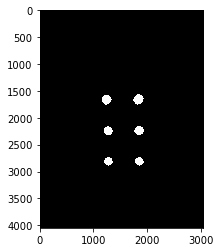

In [138]:
ret1, sure_mask = cv2.threshold(dist_transform, 0.7*dist_transform.max(), 255,cv2.THRESH_BINARY)
plt.imshow(sure_mask, cmap='gray')

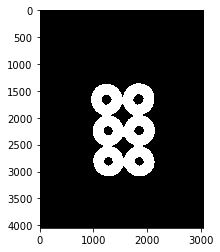

In [139]:
sure_mask = cv2.convertScaleAbs(sure_mask)
unknown = coin_thresh_water - sure_mask
plt.imshow(unknown, cmap='gray')

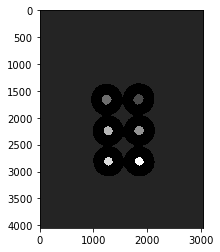

In [162]:
ret2, marker = cv2.connectedComponents(sure_mask)
marker=marker+1
marker[unknown==255] = 0   # here we created a bool mask again
plt.imshow(marker, cmap='gray') 

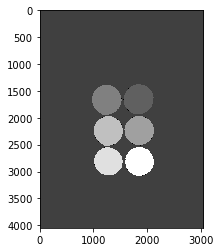

In [163]:
marker_final = cv2.watershed(img.copy(), marker)
plt.imshow(marker_final, cmap='gray')

13


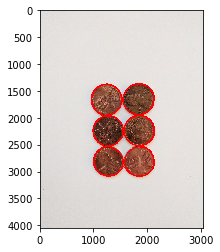

In [165]:
img2, contours, hierarchy = cv2.findContours(marker_final, cv2.RETR_CCOMP, cv2.CHAIN_APPROX_SIMPLE)
m= cv2.drawContours(img, contours, -1, (255,0,0), thickness=10)
print(len(contours))
plt.imshow(s)